正在加载LP数据...
✅ 数据加载完成，共 190 条记录

LP数据统计摘要

数据时间范围: 2025-06-09 ~ 2025-12-15
总交易日数: 190

📈 ETH价格统计:
  均值: $3,610.35
  标准差: $727.67
  最小值: $2,262.00
  最大值: $4,780.00
  价格变化率均值: 0.0021 (0.21%)

💰 LP收益统计:
  净收益均值: $31.11
  净收益标准差: $291.72
  收益率均值: 0.1370%
  收益率标准差: 3.5036%
  正收益天数: 114 (60.0%)

📉 无常损失统计:
  无常损失均值: $-66.02
  无常损失总和: $-12,544.27

💵 手续费收入统计:
  手续费收入均值: $84.53
  手续费收入总和: $16,061.00

📊 LP价格区间统计:
  价格区间宽度均值: $722.02
  价格在区间内的天数: 190 (100.0%)

绘制LP指标与ETH价格相关性分析图...


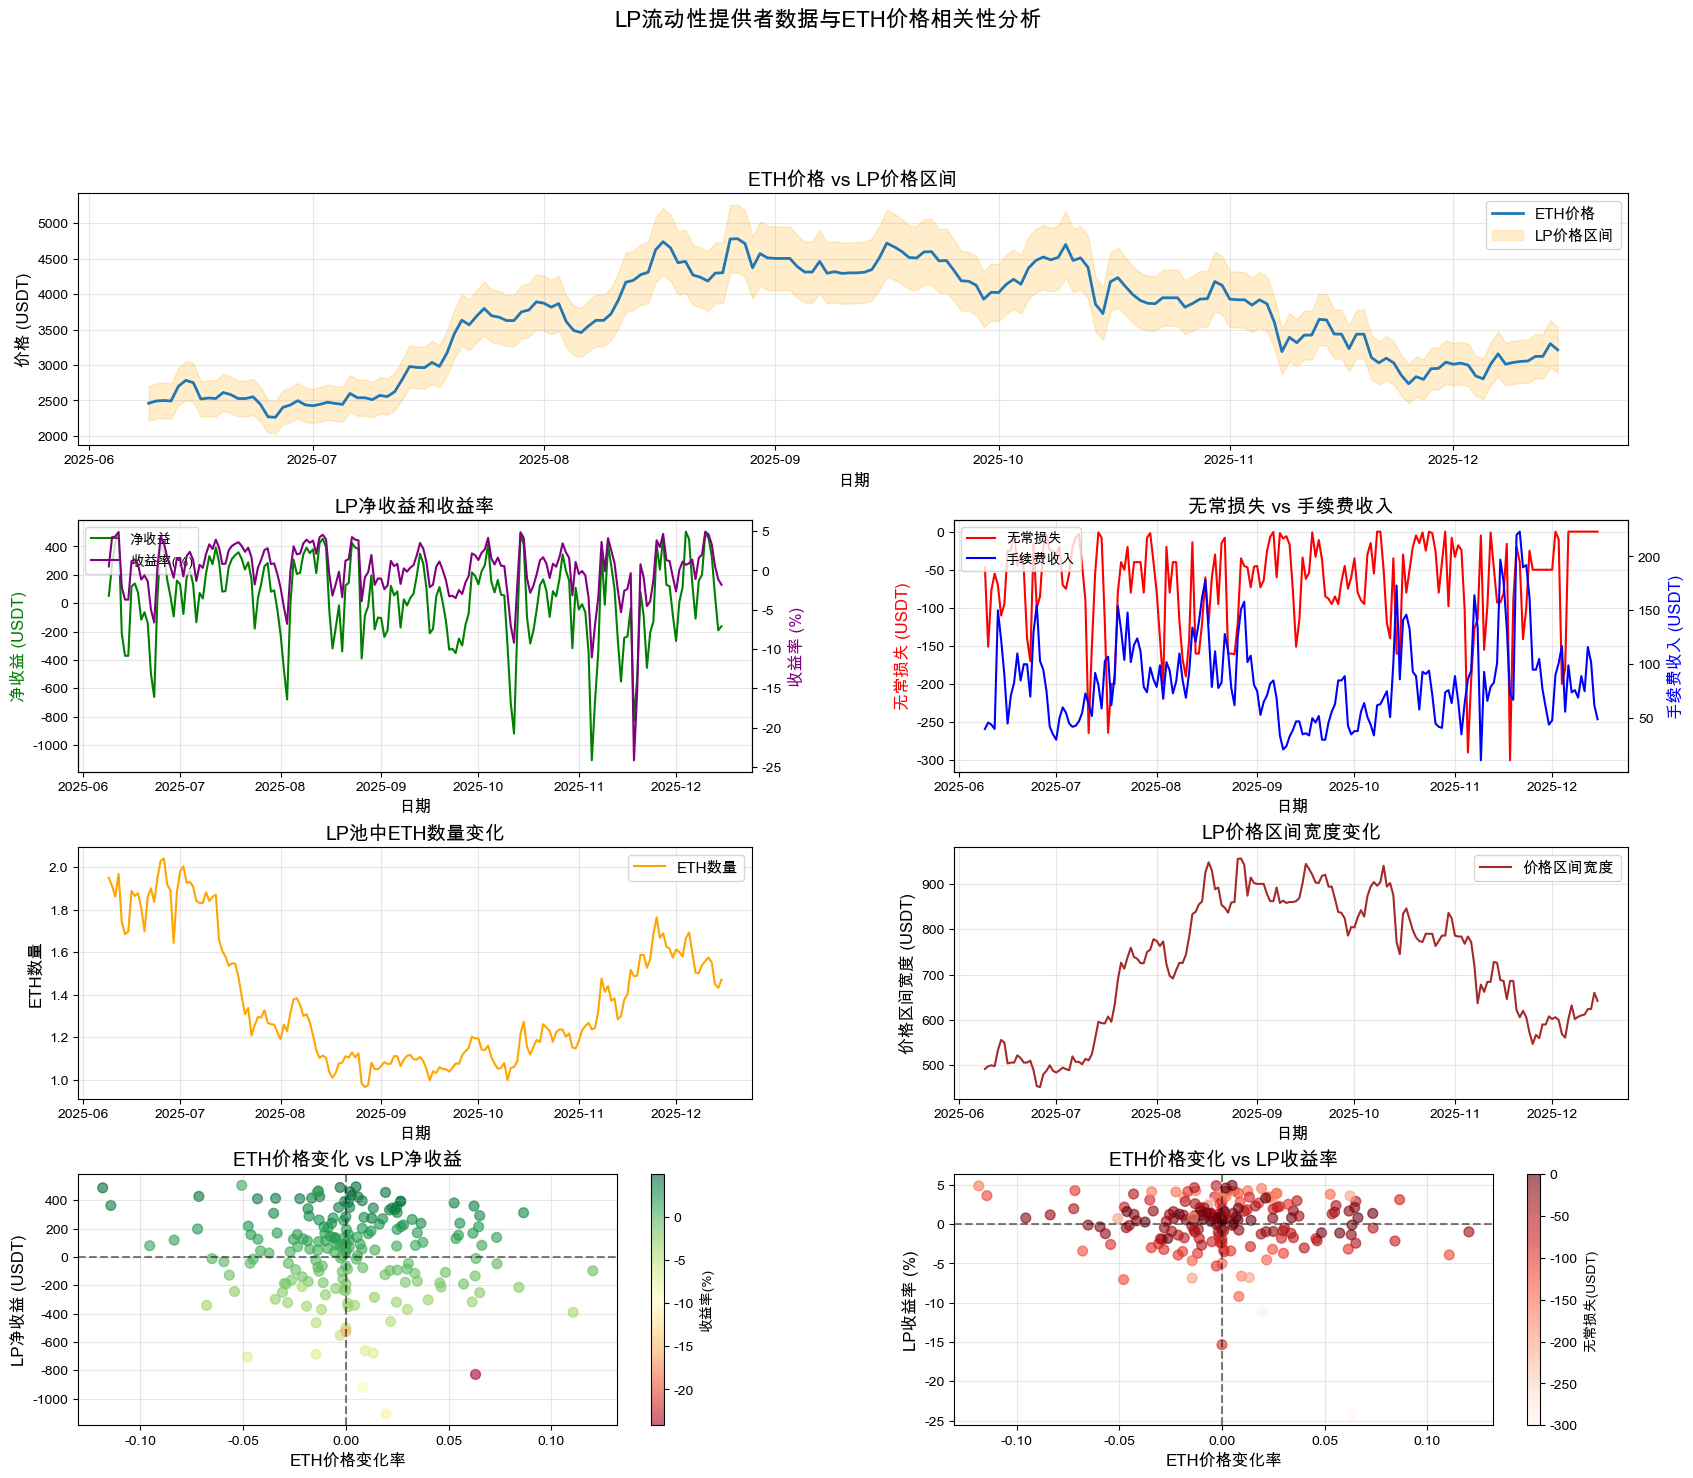


计算相关性矩阵...


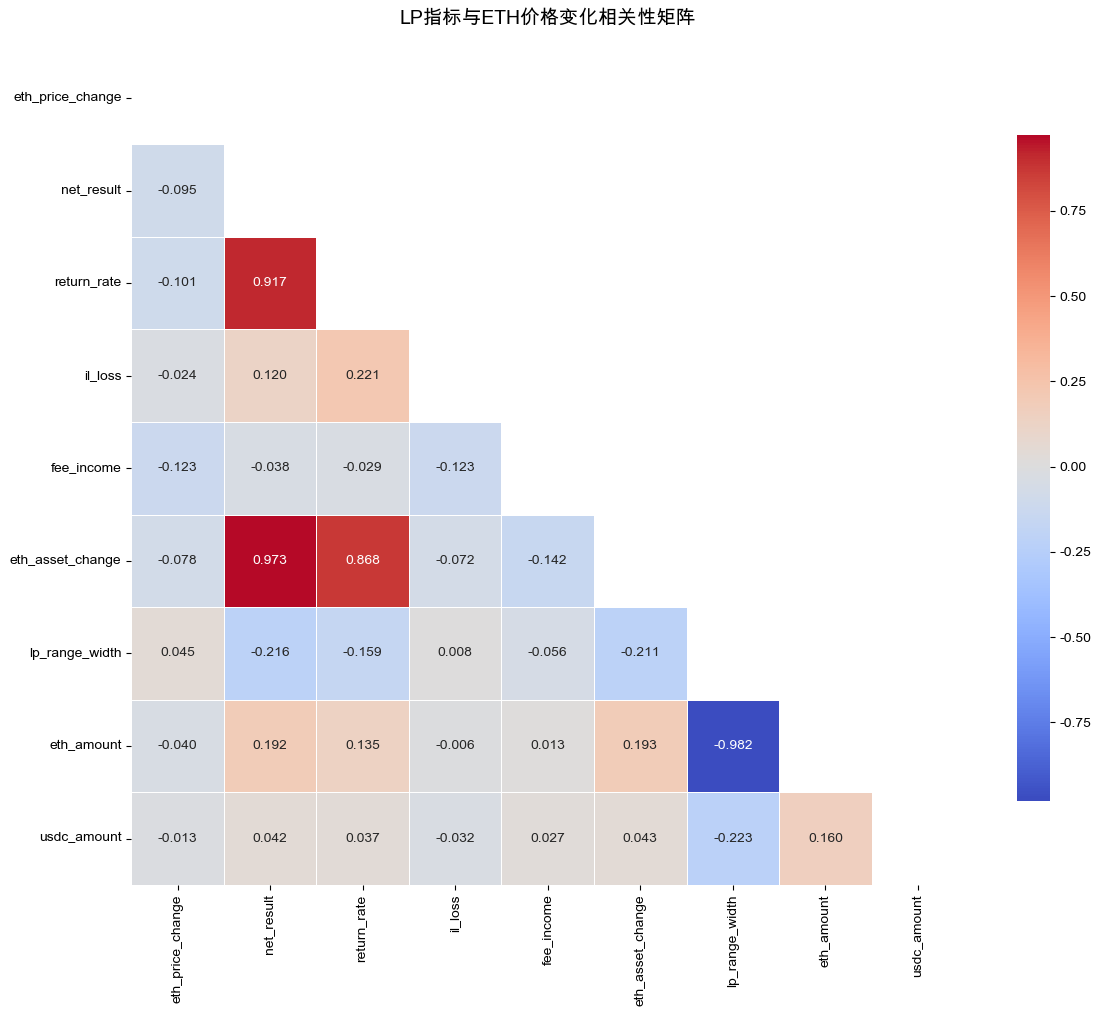


与ETH价格变化率相关性最高的指标（按绝对值排序）
fee_income          : -0.1226 (负相关, 强度: 0.1226)
return_rate         : -0.1009 (负相关, 强度: 0.1009)
net_result          : -0.0955 (负相关, 强度: 0.0955)
eth_asset_change    : -0.0779 (负相关, 强度: 0.0779)
lp_range_width      :  0.0455 (正相关, 强度: 0.0455)
eth_amount          : -0.0403 (负相关, 强度: 0.0403)
il_loss             : -0.0243 (负相关, 强度: 0.0243)
usdc_amount         : -0.0130 (负相关, 强度: 0.0130)

ETH价格大幅波动时的LP表现分析

大幅波动天数: 33 (17.4%)
大幅波动时平均净收益: $41.92
大幅波动时平均收益率: -0.1679%
大幅波动时平均无常损失: $-70.67

价格上涨时（21天）:
  平均净收益: $-1.39
  平均收益率: -0.7276%

价格下跌时（12天）:
  平均净收益: $117.73
  平均收益率: 0.8117%


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========== 1. 加载和预处理数据 ==========
def load_lp_data(csv_path='lp_only_data.csv'):
    """加载LP数据并处理日期"""
    df = pd.read_csv(csv_path)
    
    def parse_date(date_val):
        """将date转换为2025年的日期
        格式：MMDD，如 609 = 6月9日，1001 = 10月1日
        """
        date_str = str(int(date_val))
        
        if len(date_str) == 3:
            # 如 609 -> 06月09日
            month = int(date_str[0])
            day = int(date_str[1:])
        elif len(date_str) == 4:
            # 如 1001 -> 10月01日
            month = int(date_str[:2])
            day = int(date_str[2:])
        else:
            return pd.NaT
        
        try:
            return pd.Timestamp(2025, month, day)
        except:
            return pd.NaT
    
    df['date_parsed'] = df['date'].apply(parse_date)
    
    # 检查是否有解析失败的日期
    failed_dates = df[df['date_parsed'].isna()]
    if len(failed_dates) > 0:
        print(f"⚠️ 警告: 有 {len(failed_dates)} 个日期解析失败")
        print(failed_dates[['date']].head())
    
    df = df.sort_values('date_parsed').reset_index(drop=True)
    
    # 计算ETH价格变化率
    df['eth_price_change'] = df['eth_price'].pct_change()
    df['eth_price_change_abs'] = df['eth_price_change'].abs()
    
    # 计算LP价格区间宽度
    df['lp_range_width'] = df['lp_upper'] - df['lp_lower']
    df['lp_range_center'] = (df['lp_upper'] + df['lp_lower']) / 2
    df['price_in_range'] = (df['eth_price'] >= df['lp_lower']) & (df['eth_price'] <= df['lp_upper'])
    
    return df

# ========== 2. 绘制综合图表 ==========
def plot_lp_eth_correlation(df):
    """绘制LP指标与ETH价格的相关性分析图"""
    
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)
    
    # ===== 子图1: ETH价格走势 =====
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df['date_parsed'], df['eth_price'], label='ETH价格', linewidth=2, color='#1f77b4')
    ax1.fill_between(df['date_parsed'], df['lp_lower'], df['lp_upper'], 
                     alpha=0.2, color='orange', label='LP价格区间')
    ax1.set_xlabel('日期', fontsize=12)
    ax1.set_ylabel('价格 (USDT)', fontsize=12)
    ax1.set_title('ETH价格 vs LP价格区间', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # ===== 子图2: 净收益和收益率 =====
    ax2 = fig.add_subplot(gs[1, 0])
    ax2_twin = ax2.twinx()
    
    line1 = ax2.plot(df['date_parsed'], df['net_result'], label='净收益', color='green', linewidth=1.5)
    line2 = ax2_twin.plot(df['date_parsed'], df['return_rate'], label='收益率(%)', color='purple', linewidth=1.5)
    
    ax2.set_xlabel('日期', fontsize=12)
    ax2.set_ylabel('净收益 (USDT)', fontsize=12, color='green')
    ax2_twin.set_ylabel('收益率 (%)', fontsize=12, color='purple')
    ax2.set_title('LP净收益和收益率', fontsize=14, fontweight='bold')
    
    # 合并图例
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # ===== 子图3: 无常损失和手续费收入 =====
    ax3 = fig.add_subplot(gs[1, 1])
    ax3_twin = ax3.twinx()
    
    line1 = ax3.plot(df['date_parsed'], df['il_loss'], label='无常损失', color='red', linewidth=1.5)
    line2 = ax3_twin.plot(df['date_parsed'], df['fee_income'], label='手续费收入', color='blue', linewidth=1.5)
    
    ax3.set_xlabel('日期', fontsize=12)
    ax3.set_ylabel('无常损失 (USDT)', fontsize=12, color='red')
    ax3_twin.set_ylabel('手续费收入 (USDT)', fontsize=12, color='blue')
    ax3.set_title('无常损失 vs 手续费收入', fontsize=14, fontweight='bold')
    
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax3.legend(lines, labels, loc='upper left', fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    # ===== 子图4: ETH资产变化 =====
    ax4 = fig.add_subplot(gs[2, 0])
    ax4.plot(df['date_parsed'], df['eth_amount'], label='ETH数量', color='orange', linewidth=1.5)
    ax4.set_xlabel('日期', fontsize=12)
    ax4.set_ylabel('ETH数量', fontsize=12)
    ax4.set_title('LP池中ETH数量变化', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=11)
    ax4.grid(True, alpha=0.3)
    
    # ===== 子图5: LP价格区间宽度 =====
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.plot(df['date_parsed'], df['lp_range_width'], label='价格区间宽度', color='brown', linewidth=1.5)
    ax5.set_xlabel('日期', fontsize=12)
    ax5.set_ylabel('价格区间宽度 (USDT)', fontsize=12)
    ax5.set_title('LP价格区间宽度变化', fontsize=14, fontweight='bold')
    ax5.legend(fontsize=11)
    ax5.grid(True, alpha=0.3)
    
    # ===== 子图6: ETH价格变化率 vs 净收益散点图 =====
    ax6 = fig.add_subplot(gs[3, 0])
    scatter = ax6.scatter(df['eth_price_change'], df['net_result'], 
                         c=df['return_rate'], cmap='RdYlGn', alpha=0.6, s=50)
    ax6.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax6.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    ax6.set_xlabel('ETH价格变化率', fontsize=12)
    ax6.set_ylabel('LP净收益 (USDT)', fontsize=12)
    ax6.set_title('ETH价格变化 vs LP净收益', fontsize=14, fontweight='bold')
    plt.colorbar(scatter, ax=ax6, label='收益率(%)')
    ax6.grid(True, alpha=0.3)
    
    # ===== 子图7: ETH价格变化率 vs 收益率散点图 =====
    ax7 = fig.add_subplot(gs[3, 1])
    scatter = ax7.scatter(df['eth_price_change'], df['return_rate'], 
                         c=df['il_loss'], cmap='Reds', alpha=0.6, s=50)
    ax7.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax7.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    ax7.set_xlabel('ETH价格变化率', fontsize=12)
    ax7.set_ylabel('LP收益率 (%)', fontsize=12)
    ax7.set_title('ETH价格变化 vs LP收益率', fontsize=14, fontweight='bold')
    plt.colorbar(scatter, ax=ax7, label='无常损失(USDT)')
    ax7.grid(True, alpha=0.3)
    
    plt.suptitle('LP流动性提供者数据与ETH价格相关性分析', fontsize=16, fontweight='bold', y=0.995)
    plt.show()

# ========== 3. 计算相关性矩阵 ==========
def calculate_correlations(df):
    """计算各指标与ETH价格变化的相关性"""
    
    # 选择要分析的特征
    features = [
        'eth_price_change',      # ETH价格变化率
        'net_result',            # 净收益
        'return_rate',           # 收益率
        'il_loss',               # 无常损失
        'fee_income',            # 手续费收入
        'eth_asset_change',      # ETH资产变化
        'lp_range_width',        # LP价格区间宽度
        'eth_amount',            # ETH数量
        'usdc_amount'            # USDC数量
    ]
    
    # 计算相关性矩阵
    corr_matrix = df[features].corr()
    
    # 绘制相关性热力图
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 只显示下三角
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('LP指标与ETH价格变化相关性矩阵', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # 打印与ETH价格变化最相关的指标
    print("\n" + "="*60)
    print("与ETH价格变化率相关性最高的指标（按绝对值排序）")
    print("="*60)
    
    eth_corr = corr_matrix['eth_price_change'].drop('eth_price_change').abs().sort_values(ascending=False)
    
    for feature, corr_val in eth_corr.items():
        actual_corr = corr_matrix.loc[feature, 'eth_price_change']
        direction = "正相关" if actual_corr > 0 else "负相关"
        print(f"{feature:20s}: {actual_corr:7.4f} ({direction}, 强度: {corr_val:.4f})")
    
    print("="*60)
    
    return corr_matrix

# ========== 4. 统计分析 ==========
def print_statistics(df):
    """打印统计信息"""
    print("\n" + "="*60)
    print("LP数据统计摘要")
    print("="*60)
    
    print(f"\n数据时间范围: {df['date_parsed'].min().date()} ~ {df['date_parsed'].max().date()}")
    print(f"总交易日数: {len(df)}")
    
    print(f"\n📈 ETH价格统计:")
    print(f"  均值: ${df['eth_price'].mean():,.2f}")
    print(f"  标准差: ${df['eth_price'].std():,.2f}")
    print(f"  最小值: ${df['eth_price'].min():,.2f}")
    print(f"  最大值: ${df['eth_price'].max():,.2f}")
    print(f"  价格变化率均值: {df['eth_price_change'].mean():.4f} ({df['eth_price_change'].mean()*100:.2f}%)")
    
    print(f"\n💰 LP收益统计:")
    print(f"  净收益均值: ${df['net_result'].mean():,.2f}")
    print(f"  净收益标准差: ${df['net_result'].std():,.2f}")
    print(f"  收益率均值: {df['return_rate'].mean():.4f}%")
    print(f"  收益率标准差: {df['return_rate'].std():.4f}%")
    print(f"  正收益天数: {(df['net_result'] > 0).sum()} ({(df['net_result'] > 0).mean()*100:.1f}%)")
    
    print(f"\n📉 无常损失统计:")
    print(f"  无常损失均值: ${df['il_loss'].mean():,.2f}")
    print(f"  无常损失总和: ${df['il_loss'].sum():,.2f}")
    
    print(f"\n💵 手续费收入统计:")
    print(f"  手续费收入均值: ${df['fee_income'].mean():,.2f}")
    print(f"  手续费收入总和: ${df['fee_income'].sum():,.2f}")
    
    print(f"\n📊 LP价格区间统计:")
    print(f"  价格区间宽度均值: ${df['lp_range_width'].mean():,.2f}")
    print(f"  价格在区间内的天数: {(df['price_in_range']).sum()} ({(df['price_in_range']).mean()*100:.1f}%)")
    
    print("="*60)

# ========== 5. 主执行代码 ==========
# 加载数据
print("正在加载LP数据...")
df = load_lp_data('lp_only_data.csv')
print(f"✅ 数据加载完成，共 {len(df)} 条记录")

# 打印统计信息
print_statistics(df)

# 绘制综合图表
print("\n绘制LP指标与ETH价格相关性分析图...")
plot_lp_eth_correlation(df)

# 计算相关性
print("\n计算相关性矩阵...")
corr_matrix = calculate_correlations(df)

# 额外分析：价格大幅波动时的LP表现
print("\n" + "="*60)
print("ETH价格大幅波动时的LP表现分析")
print("="*60)

# 定义大幅波动：价格变化率绝对值 > 5%
large_moves = df[df['eth_price_change_abs'] > 0.05].copy()

if len(large_moves) > 0:
    print(f"\n大幅波动天数: {len(large_moves)} ({len(large_moves)/len(df)*100:.1f}%)")
    print(f"大幅波动时平均净收益: ${large_moves['net_result'].mean():,.2f}")
    print(f"大幅波动时平均收益率: {large_moves['return_rate'].mean():.4f}%")
    print(f"大幅波动时平均无常损失: ${large_moves['il_loss'].mean():,.2f}")
    
    # 上涨 vs 下跌
    up_moves = large_moves[large_moves['eth_price_change'] > 0]
    down_moves = large_moves[large_moves['eth_price_change'] < 0]
    
    if len(up_moves) > 0:
        print(f"\n价格上涨时（{len(up_moves)}天）:")
        print(f"  平均净收益: ${up_moves['net_result'].mean():,.2f}")
        print(f"  平均收益率: {up_moves['return_rate'].mean():.4f}%")
    
    if len(down_moves) > 0:
        print(f"\n价格下跌时（{len(down_moves)}天）:")
        print(f"  平均净收益: ${down_moves['net_result'].mean():,.2f}")
        print(f"  平均收益率: {down_moves['return_rate'].mean():.4f}%")
else:
    print("没有发现大幅波动（>5%）的交易日")

print("="*60)

High Risk Days (Score > 10):
          date    close  fee_income  risk_score
7   2025-06-16  2544.17        45.0   56.246962
14  2025-06-23  2411.66        70.0   13.312693
18  2025-06-27  2423.17        95.0   13.583990
19  2025-06-28  2435.62        75.0   25.012498
20  2025-06-29  2500.09        42.0   45.701357
21  2025-06-30  2485.47        35.0   41.731410
22  2025-07-01  2405.01        30.0   30.340557
39  2025-07-18  3546.92        62.0   18.652963
49  2025-07-28  3799.00        79.0   21.236291
50  2025-07-29  3793.79        74.0   17.086835
62  2025-08-10  4250.57        69.0   12.713472
70  2025-08-18  4312.99        79.0   40.801798
72  2025-08-20  4336.16        78.0   14.504932
76  2025-08-24  4780.15        78.0   15.032680
77  2025-08-25  4376.18        62.0   31.403282
81  2025-08-29  4360.18       102.0   17.050691
83  2025-08-31  4391.83        81.0   22.314578
85  2025-09-02  4326.50        53.0   29.144385
91  2025-09-08  4306.37        34.0   48.936170
92  2025-09

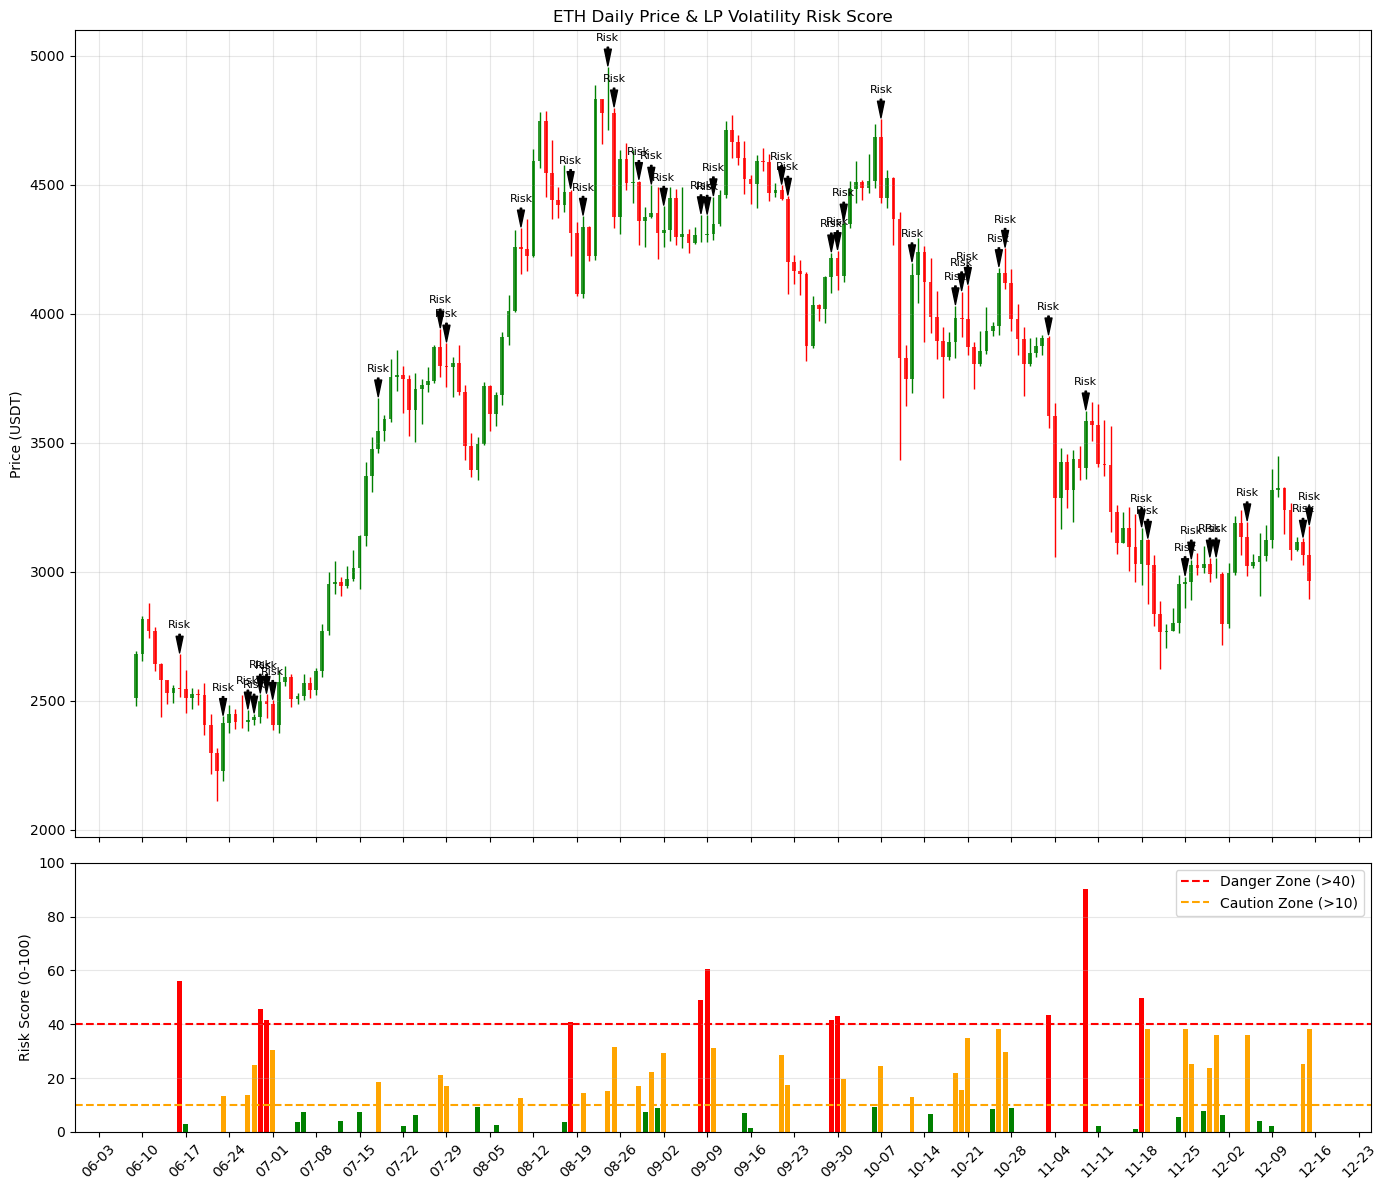

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Load Data
lp_df = pd.read_csv('lp_only_data.csv')
binance_df = pd.read_csv('../kline_data/binance_daily_klines_20251216.csv')

# 2. Process Dates
def parse_date(d_int):
    s = str(d_int).zfill(4)
    return pd.to_datetime(f"2025-{s[:2]}-{s[2:]}")

lp_df['date_parsed'] = lp_df['date'].apply(parse_date)
lp_df = lp_df.sort_values('date_parsed')

eth_df = binance_df[binance_df['symbol'] == 'ETHUSDT'].copy()
eth_df['date'] = pd.to_datetime(eth_df['date'])
eth_df = eth_df.sort_values('date')

# 3. Calculate Risk Score
# Use the formula: max(0, (0.85 - Ratio) / 0.85) * 100
lp_df['fee_ma3_prev'] = lp_df['fee_income'].shift(1).rolling(window=3).mean()
lp_df['drop_ratio'] = lp_df['fee_income'] / lp_df['fee_ma3_prev']

threshold = 0.85

def calculate_risk_score(ratio):
    if pd.isna(ratio) or np.isinf(ratio):
        return 0
    score = (threshold - ratio) / threshold
    score = max(0, score)
    score = min(1, score)
    return score * 100

lp_df['risk_score'] = lp_df['drop_ratio'].apply(calculate_risk_score)

# 4. Merge Data
merged_df = pd.merge(eth_df, lp_df[['date_parsed', 'risk_score', 'fee_income']], 
                     left_on='date', right_on='date_parsed', how='inner')

# Filter for the relevant period (LP data range)
start_date = lp_df['date_parsed'].min()
end_date = lp_df['date_parsed'].max()
plot_df = merged_df[(merged_df['date'] >= start_date) & (merged_df['date'] <= end_date)].copy()

# 5. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Top Panel: ETH Candlestick
# Draw candlesticks manually
width = 0.6
up = plot_df[plot_df.close >= plot_df.open]
down = plot_df[plot_df.close < plot_df.open]

# Up candles
ax1.bar(up.date, up.close - up.open, width, bottom=up.open, color='green', alpha=0.8)
ax1.vlines(up.date, up.low, up.high, color='green', linewidth=1)

# Down candles
ax1.bar(down.date, down.open - down.close, width, bottom=down.close, color='red', alpha=0.8)
ax1.vlines(down.date, down.low, down.high, color='red', linewidth=1)

ax1.set_title('ETH Daily Price & LP Volatility Risk Score')
ax1.set_ylabel('Price (USDT)')
ax1.grid(True, alpha=0.3)

# Highlight high risk days on price chart
high_risk = plot_df[plot_df['risk_score'] > 10]
for idx, row in high_risk.iterrows():
    ax1.annotate('Risk', xy=(row['date'], row['high']), xytext=(row['date'], row['high'] + 100),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                 horizontalalignment='center', color='black', fontsize=8)

# Bottom Panel: Risk Score
# Color bars based on risk level
colors = []
for score in plot_df['risk_score']:
    if score > 40:
        colors.append('red') # Danger
    elif score > 10:
        colors.append('orange') # Caution
    else:
        colors.append('green') # Safe

ax2.bar(plot_df['date'], plot_df['risk_score'], color=colors, width=0.8)
ax2.axhline(40, color='red', linestyle='--', label='Danger Zone (>40)')
ax2.axhline(10, color='orange', linestyle='--', label='Caution Zone (>10)')
ax2.set_ylabel('Risk Score (0-100)')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, axis='y', alpha=0.3)

# Format X axis dates
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=7)) # Show date every week
plt.xticks(rotation=45)

plt.tight_layout()
# plt.savefig('eth_price_risk_score.png')

# 6. Output Table
# Show only days with non-zero risk score for brevity, or top risk days
print("High Risk Days (Score > 10):")
risk_table = plot_df[plot_df['risk_score'] > 10][['date', 'close', 'fee_income', 'risk_score']].sort_values('date')
print(risk_table)

# Save full table to csv if needed, but printing is requested
risk_table_full = plot_df[['date', 'risk_score', 'close', 'fee_income']].copy()
risk_table_full['date'] = risk_table_full['date'].dt.strftime('%Y-%m-%d')
print("\nRecent 10 Days Risk Score:")
print(risk_table_full.tail(10))